In [1]:
import sys
!"{sys.executable}" -m pip install openpyxl


[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd

df = pd.read_excel("Telco_customer_churn.xlsx")
df.head()
print(df.shape)      # rows, columns
df.info()            # data types + missing values
df.isna().sum().head(20)

(7043, 33)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Serv

CustomerID           0
Count                0
Country              0
State                0
City                 0
Zip Code             0
Lat Long             0
Latitude             0
Longitude            0
Gender               0
Senior Citizen       0
Partner              0
Dependents           0
Tenure Months        0
Phone Service        0
Multiple Lines       0
Internet Service     0
Online Security      0
Online Backup        0
Device Protection    0
dtype: int64

In [3]:
import numpy as np

# 1) Fix Total Charges (it's object right now)
df["Total Charges"] = pd.to_numeric(df["Total Charges"], errors="coerce")

# 2) If any became NaN, fill them (usually tenure=0 customers)
# Option A: fill with 0
df["Total Charges"] = df["Total Charges"].fillna(0)

# Quick verify
print(df[["Total Charges"]].isna().sum())
print(df["Total Charges"].dtype)

Total Charges    0
dtype: int64
float64


In [4]:
# Target: use Churn Value (0/1)
y = df["Churn Value"]

# Start with all columns except the target
X = df.drop(columns=["Churn Value"])

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (7043, 32)
y shape: (7043,)


In [5]:
cols_to_drop = [
    "CustomerID",
    "Count",
    "Country",
    "State",
    "City",
    "Zip Code",
    "Lat Long",
    "Latitude",
    "Longitude",
    "Churn Label",   # leakage
    "Churn Score",   # leakage
    "Churn Reason"   # leakage + lots of missing
]

X_clean = X.drop(columns=[c for c in cols_to_drop if c in X.columns])

print("After dropping columns:", X_clean.shape)
print(X_clean.dtypes.value_counts())

After dropping columns: (7043, 20)
object     16
int64       2
float64     2
Name: count, dtype: int64


In [6]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Identify column types
cat_cols = X_clean.select_dtypes(include=["object"]).columns
num_cols = X_clean.select_dtypes(exclude=["object"]).columns

# Preprocessing: scale numeric + encode categorical
preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore", drop="first"), cat_cols)
    ]
)

# Logistic Regression model
pipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", LogisticRegression(max_iter=5000, class_weight="balanced"))
])

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_clean, y, test_size=0.20, random_state=42, stratify=y
)

# Train model
pipe.fit(X_train, y_train)

# Predictions
y_pred = pipe.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.7423704755145494

Confusion Matrix:
 [[753 282]
 [ 81 293]]

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.73      0.81      1035
           1       0.51      0.78      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.76      1409



ROC-AUC Score: 0.8489963574362551


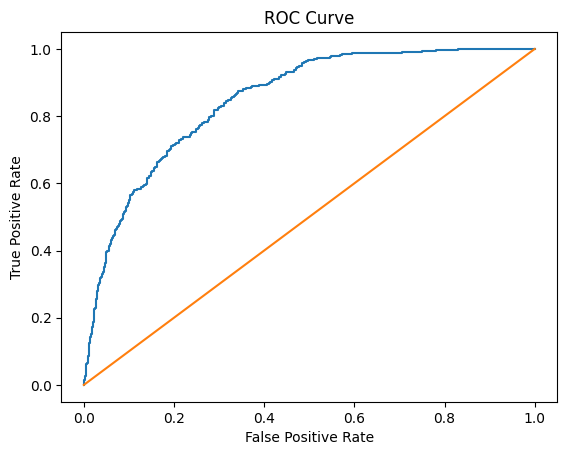

In [7]:
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# Predict probabilities
y_prob = pipe.predict_proba(X_test)[:, 1]

# AUC
auc = roc_auc_score(y_test, y_prob)
print("ROC-AUC Score:", auc)

# Plot ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure()
plt.plot(fpr, tpr)
plt.plot([0,1],[0,1])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

In [8]:
# Assume:
avg_monthly_revenue = 70
retention_success_rate = 0.30  # 30% of contacted churners stay

# True positives = correctly identified churners
tp = 293

customers_saved = tp * retention_success_rate
revenue_saved = customers_saved * avg_monthly_revenue * 12

print("Estimated Customers Saved:", int(customers_saved))
print("Estimated Annual Revenue Saved: $", int(revenue_saved))

Estimated Customers Saved: 87
Estimated Annual Revenue Saved: $ 73835


In [9]:
from sklearn.ensemble import RandomForestClassifier

rf = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", RandomForestClassifier(random_state=42))
])

rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))
print(classification_report(y_test, rf_pred))

Random Forest Accuracy: 0.8090844570617459
              precision    recall  f1-score   support

           0       0.84      0.91      0.88      1035
           1       0.68      0.53      0.60       374

    accuracy                           0.81      1409
   macro avg       0.76      0.72      0.74      1409
weighted avg       0.80      0.81      0.80      1409



In [10]:
import numpy as np

# Get feature names after preprocessing
ohe = pipe.named_steps["preprocess"].named_transformers_["cat"]
encoded_cat_cols = ohe.get_feature_names_out(cat_cols)

all_feature_names = np.concatenate([num_cols, encoded_cat_cols])

# Get coefficients from logistic regression
coefficients = pipe.named_steps["model"].coef_[0]

feature_importance = pd.Series(coefficients, index=all_feature_names)
feature_importance = feature_importance.sort_values(ascending=False)

print("Top 10 Features Increasing Churn:\n")
print(feature_importance.head(10))

print("\nTop 10 Features Decreasing Churn:\n")
print(feature_importance.tail(10))

Top 10 Features Increasing Churn:

Internet Service_Fiber optic       1.032129
Total Charges                      0.503277
Payment Method_Electronic check    0.396672
Streaming Movies_Yes               0.365192
Streaming TV_Yes                   0.345097
Multiple Lines_Yes                 0.322591
Paperless Billing_Yes              0.322108
Partner_Yes                        0.278812
Payment Method_Mailed check        0.035402
Senior Citizen_Yes                 0.032324
dtype: float64

Top 10 Features Decreasing Churn:

Online Security_No internet service   -0.157648
Internet Service_No                   -0.157648
Tech Support_Yes                      -0.283277
Online Security_Yes                   -0.320161
Phone Service_Yes                     -0.334320
Monthly Charges                       -0.418732
Contract_One year                     -0.774775
Tenure Months                         -1.213567
Contract_Two year                     -1.388642
Dependents_Yes                        -1.6

In [11]:
churn_by_contract = df.groupby("Contract")["Churn Value"].mean().sort_values(ascending=False)
print(churn_by_contract)

Contract
Month-to-month    0.427097
One year          0.112695
Two year          0.028319
Name: Churn Value, dtype: float64


In [12]:
churn_by_internet = df.groupby("Internet Service")["Churn Value"].mean().sort_values(ascending=False)
print(churn_by_internet)

Internet Service
Fiber optic    0.418928
DSL            0.189591
No             0.074050
Name: Churn Value, dtype: float64


In [13]:
df["Tenure_Group"] = pd.cut(df["Tenure Months"],
                            bins=[0,12,24,48,72],
                            labels=["0-1 yr","1-2 yr","2-4 yr","4-6 yr"])

churn_by_tenure = df.groupby("Tenure_Group")["Churn Value"].mean()
print(churn_by_tenure)

Tenure_Group
0-1 yr    0.476782
1-2 yr    0.287109
2-4 yr    0.203890
4-6 yr    0.095132
Name: Churn Value, dtype: float64


C:\Users\akhil rockyy\AppData\Local\Temp\ipykernel_3004\1382098385.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  churn_by_tenure = df.groupby("Tenure_Group")["Churn Value"].mean()
